<a href="https://colab.research.google.com/github/marcoskantor/Curso_Introduccion_Ingenieria_Datos/blob/main/Proyecto_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# ============================================================
# Celda 1: Setup completo del entorno de trabajo
# ============================================================
# - Clona el repo (o lo actualiza si ya existe)
# - Configura git con el usuario real
# - Autentica con GitHub vía Personal Access Token (Colab Secrets)
# - Instala dependencias
# ============================================================

import os
import shutil
from google.colab import userdata

# --- 1.1 Clonar o entrar al repo ---
REPO_URL   = "https://github.com/marcoskantor/Curso_Introduccion_Ingenieria_Datos.git"
REPO_NAME  = "Curso_Introduccion_Ingenieria_Datos"
REPO_PATH  = f"/content/{REPO_NAME}"

%cd /content

if os.path.exists(REPO_PATH):
    if os.path.exists(f"{REPO_PATH}/.git"):
        print(f"✅ Repo ya existe en {REPO_PATH}.")
    else:
        print(f"⚠️  Carpeta {REPO_PATH} sin .git. Borrando y re-clonando...")
        shutil.rmtree(REPO_PATH)
        !git clone {REPO_URL}
else:
    print("⏳ Clonando repositorio...")
    !git clone {REPO_URL}

%cd {REPO_PATH}

# --- 1.2 Configurar identidad de git ---
!git config user.name "Marcos Kantor"
!git config user.email "marcoskantor@gmail.com"

# --- 1.3 Autenticar con GitHub vía Colab Secrets ---
try:
    GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
    os.environ["GITHUB_TOKEN"] = GITHUB_TOKEN
    !git remote set-url origin https://$GITHUB_TOKEN@github.com/marcoskantor/{REPO_NAME}.git
    print("✅ Autenticación GitHub configurada (token desde Colab Secrets).")
except Exception as e:
    print("⚠️  No se encontró GITHUB_TOKEN en Colab Secrets.")
    print("   El repo funciona para leer, pero NO podrás hacer git push.")
    print("   Para configurarlo:")
    print("   1. https://github.com/settings/tokens → Generate new token (classic) → scope: repo")
    print("   2. Colab → 🔑 → Add new secret → Name: GITHUB_TOKEN → pegar el ghp_...")
    print("   3. Activar 'Notebook access'")
    print(f"   Detalle: {e}")

# --- 1.4 Instalar dependencias ---
if os.path.exists("requirements.txt"):
    print("⏳ Instalando dependencias desde requirements.txt...")
    !pip install -q -r requirements.txt
    print("✅ Dependencias instaladas.")
else:
    print("⚠️  requirements.txt no encontrado. Instalando dependencias base...")
    !pip install -q pandas numpy roboflow matplotlib seaborn plotly streamlit pyngrok tqdm Pillow scikit-learn scipy
    print("✅ Dependencias base instaladas (fallback).")

# --- 1.5 Verificación final ---
print("\n" + "=" * 60)
print("ESTADO DEL ENTORNO")
print("=" * 60)
!git status
print("\n📁 Contenido del repo:")
!ls -la

/content
✅ Repo ya existe en /content/Curso_Introduccion_Ingenieria_Datos.
/content/Curso_Introduccion_Ingenieria_Datos
✅ Autenticación GitHub configurada (token desde Colab Secrets).
⏳ Instalando dependencias desde requirements.txt...
✅ Dependencias instaladas.

ESTADO DEL ENTORNO
On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	spine_annotations.csv

nothing added to commit but untracked files present (use "git add" to track)

📁 Contenido del repo:
total 480
drwxr-xr-x 7 root root   4096 Oct  1 13:41 .
drwxr-xr-x 1 root root   4096 Oct  1 13:12 ..
drwxr-xr-x 4 root root   4096 Oct  1 13:12 data
drwxr-xr-x 8 root root   4096 Oct  1 13:46 .git
-rw-r--r-- 1 root root    277 Oct  1 13:18 .gitignore
drwxr-xr-x 2 root root   4096 Oct  1 13:12 notebooks
-rw-r--r-- 1 root root   2163 Oct  1 13:12 README.md
-rw-r--r-- 1 root root    218 Oct  1 13:18 requirements.txt
-rw-r--r-- 1 root root  28156 Oc

In [18]:
# ============================================================
# Celda 2: Push autenticado (arreglado)
# ============================================================
import os
from google.colab import userdata

%cd /content/Curso_Introduccion_Ingenieria_Datos

# Leer token de Secrets
GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
print(f"Token leído: {GITHUB_TOKEN[:7]}...{GITHUB_TOKEN[-4:]}")  # muestra solo inicio y fin

# Reescribir el remote con el token real embebido
!git remote set-url origin https://{GITHUB_TOKEN}@github.com/marcoskantor/Curso_Introduccion_Ingenieria_Datos.git

# Verificar que la URL quedó bien (enmascarando el token)
!git remote -v | sed -E 's/ghp_[A-Za-z0-9]+/ghp_***MASKED***/g'

# Push
!git push origin main


/content/Curso_Introduccion_Ingenieria_Datos
Token leído: ghp_ZzU...16tc
origin	https://ghp_***MASKED***@github.com/marcoskantor/Curso_Introduccion_Ingenieria_Datos.git (fetch)
origin	https://ghp_***MASKED***@github.com/marcoskantor/Curso_Introduccion_Ingenieria_Datos.git (push)
Everything up-to-date


# Proyecto Final — Entregable Técnico
## Detección de Vértebras Lumbares para Evaluación de Inestabilidad Espinal

**Tesista:** Marcos Kantor  
**Director:** Ramiro M. Irastorza (IFLySiB-CONICET)  
**Codirector:** Marcelo A. Cappelletti (LEICI-CONICET, UNAJ)  
**Materia:** (20262Q) DIA.04 — Introducción a la Ingeniería de Datos — Comisión A  
**Institución:** Universidad Nacional Arturo Jauretche

---

### Pregunta de investigación

¿Es el dataset público de vértebras lumbares (L1–L5) apto, en términos de calidad, balance de clases y cobertura anatómica, para entrenar un sistema de soporte a la decisión clínica (CDSS) orientado al cálculo automatizado del **Spinal Instability Neoplastic Score (SINS)**?

### Objetivo del entregable

Implementar un pipeline completo de Ingeniería de Datos sobre un dataset crudo de imágenes médicas anotadas con bounding boxes, que incluya:

1. Extracción, Transformación y Carga (ETL) hacia una base transaccional SQLite normalizada en 2NF.
2. Modelado dimensional en SQLite (esquema estrella + copo de nieve).
3. Interfaz interactiva de visualización que transmita un mensaje claro sobre la aptitud del dataset para la investigación de tesis.

## Declaración de uso de IA

En cumplimiento del requisito de la cátedra, se declara de forma transparente el uso de herramientas de Inteligencia Artificial generativa durante la elaboración de este entregable:

- **"Claude Sonnet 4.5"** para "asistir en la redacción de celdas Markdown explicativas y justificaciones metodológicas".
- **"ChatGPT 4.5"** para "sugerir estructuras de esquemas SQLite (2NF y estrella/copo de nieve) a partir del análisis del dataset".
- **"GitHub Copilot"** para "autocompletar fragmentos de código Python relacionados con parsing de anotaciones YOLO y visualizaciones con Plotly/Streamlit".

Todo el código fue revisado, adaptado y ejecutado por el autor. Las decisiones metodológicas (tratamiento de NAs, outliers, elección de dimensión anatómica, etc.) son responsabilidad exclusiva del tesista.

## Fuente del dataset

| Campo | Valor |
|---|---|
| **Nombre** | lumbar-spine-vpxwf |
| **Workspace** | rp-team |
| **Plataforma** | Roboflow Universe |
| **URL** | https://universe.roboflow.com/rp-team/lumbar-spine-vpxwf |
| **Tipo de tarea** | Object Detection |
| **Formato de export** | YOLOv8 |
| **Clases** | L1, L2, L3, L4, L5 + grupo combinado |
| **Acceso** | Público (vía SDK de Roboflow con API key) |

### Justificación

El dataset es afín al tema de tesis (*Inteligencia Artificial para la Evaluación de Inestabilidad Espinal*) porque:

1. Trabaja sobre vértebras lumbares, segmento anatómico crítico para metástasis vertebrales (MV).
2. Su formato de detección (bounding boxes) es directamente compatible con las etapas iniciales del pipeline del CDSS basado en SINS.
3. Está disponible en una fuente pública y reproducible (Roboflow Universe), sin requerir subida manual de archivos.

### Reproducibilidad

La API key de Roboflow **no está hardcodeada** en el notebook. Se gestiona vía **Colab Secrets** bajo el nombre `ROBOFLOW_API_KEY`, garantizando que cualquier persona con su propia cuenta pueda reproducir el pipeline sin exponer credenciales.

In [19]:
# ============================================================
# Celda 4: Instalación de dependencias
# ============================================================
!pip install -q roboflow streamlit pyngrok plotly seaborn

In [20]:
# ============================================================
# Celda 5: Configuración segura de la API key
# ============================================================
# La API key se lee desde Colab Secrets (ícono 🔑 en la barra lateral)
# Nombre del secret: ROBOFLOW_API_KEY
# No se hardcodea ninguna credencial en el notebook.

from google.colab import userdata

try:
    ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
    print("✅ API key leída correctamente desde Colab Secrets.")
except Exception as e:
    raise RuntimeError(
        "❌ No se encontró ROBOFLOW_API_KEY en Colab Secrets. "
        "Agregala en el panel de Secrets (🔑) y activá el toggle de acceso al notebook."
    ) from e

✅ API key leída correctamente desde Colab Secrets.


In [21]:
# ============================================================
# Celda 6: Descarga del dataset vía Roboflow SDK
# ============================================================
from roboflow import Roboflow
import os

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
workspace = rf.workspace("rp-team")
project = workspace.project("lumbar-spine-vpxwf")

# IMPORTANTE: reemplazá el número de versión por el que uses en Roboflow
version = project.version(1)

dataset = version.download("yolov8", location="spine_dataset", overwrite=True)

print(f"✅ Dataset descargado en: {dataset.location}")

# Estructura generada por Roboflow:
# spine_dataset/
# ├── train/images/  + train/labels/
# ├── valid/images/  + valid/labels/
# ├── test/images/   + test/labels/
# ├── data.yaml
# └── README.dataset.txt

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to spine_dataset in yolov8:: 100%|██████████| 103/103 [00:00<00:00, 981.13it/s]


✅ Dataset descargado en: /content/Curso_Introduccion_Ingenieria_Datos/spine_dataset


In [22]:
# ============================================================
# Celda 7: Exploración de la estructura del dataset
# ============================================================
from pathlib import Path

DATASET_ROOT = Path("spine_dataset")

def resumen_split(split_name):
    img_dir = DATASET_ROOT / split_name / "images"
    lbl_dir = DATASET_ROOT / split_name / "labels"
    n_imgs = len(list(img_dir.glob("*.jpg"))) + len(list(img_dir.glob("*.png")))
    n_lbls = len(list(lbl_dir.glob("*.txt")))
    return n_imgs, n_lbls

for split in ["train", "valid", "test"]:
    n_img, n_lbl = resumen_split(split)
    print(f"{split:6s} → imágenes: {n_img:4d} | etiquetas: {n_lbl:4d}")

# Leer data.yaml para obtener los nombres de las clases
import yaml
with open(DATASET_ROOT / "data.yaml", "r") as f:
    data_yaml = yaml.safe_load(f)

print("\n📋 Clases declaradas en data.yaml:")
print(data_yaml.get("names"))
print(f"\nCantidad de clases: {data_yaml.get('nc')}")

train  → imágenes:   50 | etiquetas:   50
valid  → imágenes:    0 | etiquetas:    0
test   → imágenes:    0 | etiquetas:    0

📋 Clases declaradas en data.yaml:
['L1', 'L2', 'L3', 'L4', 'L5']

Cantidad de clases: 5


In [23]:
# ============================================================
# Celda 7-bis: Diagnóstico de la estructura descargada
# ============================================================
from pathlib import Path

DATASET_ROOT = Path("spine_dataset")

print("=" * 70)
print("ÁRBOL COMPLETO DEL DATASET")
print("=" * 70)
for p in sorted(DATASET_ROOT.rglob("*")):
    if p.is_dir():
        print(f"[DIR]  {p}/")
    else:
        print(f"       {p}")

print("\n" + "=" * 70)
print("CONTENIDO DE data.yaml")
print("=" * 70)
yaml_path = DATASET_ROOT / "data.yaml"
if yaml_path.exists():
    print(yaml_path.read_text())
else:
    # A veces Roboflow pone el data.yaml en una subcarpeta
    for candidate in DATASET_ROOT.rglob("data.yaml"):
        print(f"Encontrado en: {candidate}")
        print(candidate.read_text())
        break

print("\n" + "=" * 70)
print("PRIMEROS LABELS DE TRAIN")
print("=" * 70)
train_labels = sorted((DATASET_ROOT / "train" / "labels").glob("*.txt"))
print(f"Total de archivos .txt en train/labels: {len(train_labels)}")
if train_labels:
    ejemplo = train_labels[0]
    print(f"\nEjemplo: {ejemplo.name}")
    print("Contenido:")
    print(ejemplo.read_text())
else:
    # Buscar labels en cualquier parte del dataset
    print("\n⚠️  No hay labels en train/labels. Buscando en todo el dataset:")
    todos_txt = list(DATASET_ROOT.rglob("*.txt"))
    for t in todos_txt[:10]:
        print(f"  → {t}")

ÁRBOL COMPLETO DEL DATASET
       spine_dataset/README.dataset.txt
       spine_dataset/README.roboflow.txt
       spine_dataset/data.yaml
[DIR]  spine_dataset/train/
[DIR]  spine_dataset/train/images/
       spine_dataset/train/images/N14-S-59-F_1002_1_jpg.rf.ee168f959b1f02054df4753ac74acdd8.jpg
       spine_dataset/train/images/N140-Rt-TAIS-F-15-Yrs_jpg.rf.679daaff863c10a15fe434ad15a10e12.jpg
       spine_dataset/train/images/N141-Rt-TAIS-F-15-Yrs_jpg.rf.e37170afb759368eb90f2c9c6e7f48fc.jpg
       spine_dataset/train/images/N142-Rt-TL-AIS-F-15-Yrs_jpg.rf.f3bc57827a64eb9eaf13ef6e9e1699e9.jpg
       spine_dataset/train/images/N143-Rt-TAIS-F-14-Yrs_jpg.rf.dea5ad28aa93202c5dc2017f40541908.jpg
       spine_dataset/train/images/N144-Rt-T-and-LT-L-AIS-M-15-Yrs_jpg.rf.ce5c889b48464afc3dbc68e38db6ea9e.jpg
       spine_dataset/train/images/N145-Rt-TAIS-M-14-Yrs_jpg.rf.296b6cf1564587a0b6d9282d341367b6.jpg
       spine_dataset/train/images/N146-Rt-TAIS-M-16-Yrs_jpg.rf.095923be75b8264511b16258814

In [24]:
# ============================================================
# Celda 8 (v2): Parser robusto — soporta bbox YOLO y polígonos
# ============================================================
import pandas as pd
import numpy as np
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm
import yaml

DATASET_ROOT = Path("spine_dataset")

# --- 8.1 Cargar nombres de clases ---
data_yaml = yaml.safe_load((DATASET_ROOT / "data.yaml").read_text())
class_names = data_yaml["names"]
if isinstance(class_names, dict):
    class_names = [class_names[k] for k in sorted(class_names.keys())]
print(f"📋 Clases detectadas: {class_names}")

# --- 8.2 Detectar splits disponibles ---
def detectar_splits(root):
    splits = {}
    for img_dir in root.rglob("images"):
        if not img_dir.is_dir():
            continue
        lbl_dir = img_dir.parent / "labels"
        if not lbl_dir.exists():
            continue
        split_name = img_dir.parent.name
        splits[split_name] = (img_dir, lbl_dir)
    return splits

splits_detectados = detectar_splits(DATASET_ROOT)
print(f"\n📂 Splits detectados: {list(splits_detectados.keys())}")
for s, (img_d, lbl_d) in splits_detectados.items():
    n_img = len([f for f in img_d.iterdir() if f.is_file()])
    n_lbl = len(list(lbl_d.glob("*.txt")))
    print(f"   {s:8s} → {n_img} imágenes, {n_lbl} labels")

# --- 8.3 Parser que maneja AMBOS formatos ---
def parsear_labels(img_dir, lbl_dir, split_name, class_names):
    registros = []
    extensiones = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff", "*.JPG")
    imagenes = []
    for ext in extensiones:
        imagenes.extend(img_dir.glob(ext))
    imagenes = sorted(set(imagenes))

    for img_path in tqdm(imagenes, desc=f"Procesando {split_name}"):
        try:
            with Image.open(img_path) as im:
                W, H = im.size
        except Exception:
            continue

        label_path = lbl_dir / (img_path.stem + ".txt")
        if not label_path.exists():
            continue

        contenido = label_path.read_text().strip()
        if not contenido:
            continue

        for ln in contenido.splitlines():
            partes = ln.strip().split()
            if len(partes) < 5:
                continue
            try:
                cls_id = int(float(partes[0]))
                vals = list(map(float, partes[1:]))
            except ValueError:
                continue

            # --- Detectar formato ---
            if len(vals) == 4:
                # YOLO bbox: xc, yc, w, h (normalizados)
                xc, yc, w, h = vals
                bbox_xc, bbox_yc = xc, yc
                bbox_w_norm, bbox_h_norm = w, h
                formato = "bbox"

            elif len(vals) >= 6 and len(vals) % 2 == 0:
                # Polígono: x1 y1 x2 y2 ... xn yn (normalizados)
                xs = vals[0::2]
                ys = vals[1::2]
                x_min, x_max = min(xs), max(xs)
                y_min, y_max = min(ys), max(ys)
                bbox_xc = (x_min + x_max) / 2
                bbox_yc = (y_min + y_max) / 2
                bbox_w_norm = x_max - x_min
                bbox_h_norm = y_max - y_min
                formato = "polygon"

            else:
                continue

            # --- Desnormalizar a píxeles ---
            bbox_w = bbox_w_norm * W
            bbox_h = bbox_h_norm * H
            bbox_x = bbox_xc * W - bbox_w / 2
            bbox_y = bbox_yc * H - bbox_h / 2

            registros.append({
                "filename": img_path.name,
                "split": split_name,
                "image_width": W,
                "image_height": H,
                "class_id": cls_id,
                "class_name": class_names[cls_id] if 0 <= cls_id < len(class_names) else f"cls_{cls_id}",
                "bbox_x": bbox_x,
                "bbox_y": bbox_y,
                "bbox_w": bbox_w,
                "bbox_h": bbox_h,
                "formato_origen": formato,
            })

    return registros

# --- 8.4 Parsear todos los splits disponibles ---
todos_registros = []
for split_name, (img_dir, lbl_dir) in splits_detectados.items():
    todos_registros.extend(parsear_labels(img_dir, lbl_dir, split_name, class_names))

df = pd.DataFrame(todos_registros)

# --- 8.5 Verificación ---
print("\n" + "=" * 60)
if len(df) == 0:
    print("⚠️  Sigue sin parsear. Revisar formato de labels.")
else:
    print(f"📊 Total de anotaciones: {len(df):,}")
    print(f"🖼️  Imágenes únicas: {df['filename'].nunique():,}")
    print(f"\nFormatos detectados:")
    print(df["formato_origen"].value_counts().to_string())
    print(f"\nDistribución por split:")
    print(df.groupby("split").agg(
        imagenes=("filename", "nunique"),
        anotaciones=("filename", "size"),
    ))
    print(f"\nDistribución por clase:")
    print(df["class_name"].value_counts().sort_index())

# Guardar para las celdas siguientes
df.to_csv("spine_annotations.csv", index=False)
print("\n✅ Guardado en spine_annotations.csv")

📋 Clases detectadas: ['L1', 'L2', 'L3', 'L4', 'L5']

📂 Splits detectados: ['train']
   train    → 50 imágenes, 50 labels


Procesando train:   0%|          | 0/50 [00:00<?, ?it/s]


📊 Total de anotaciones: 170
🖼️  Imágenes únicas: 34

Formatos detectados:
formato_origen
polygon    170

Distribución por split:
       imagenes  anotaciones
split                       
train        34          170

Distribución por clase:
class_name
L1    33
L2    35
L3    34
L4    34
L5    34
Name: count, dtype: int64

✅ Guardado en spine_annotations.csv


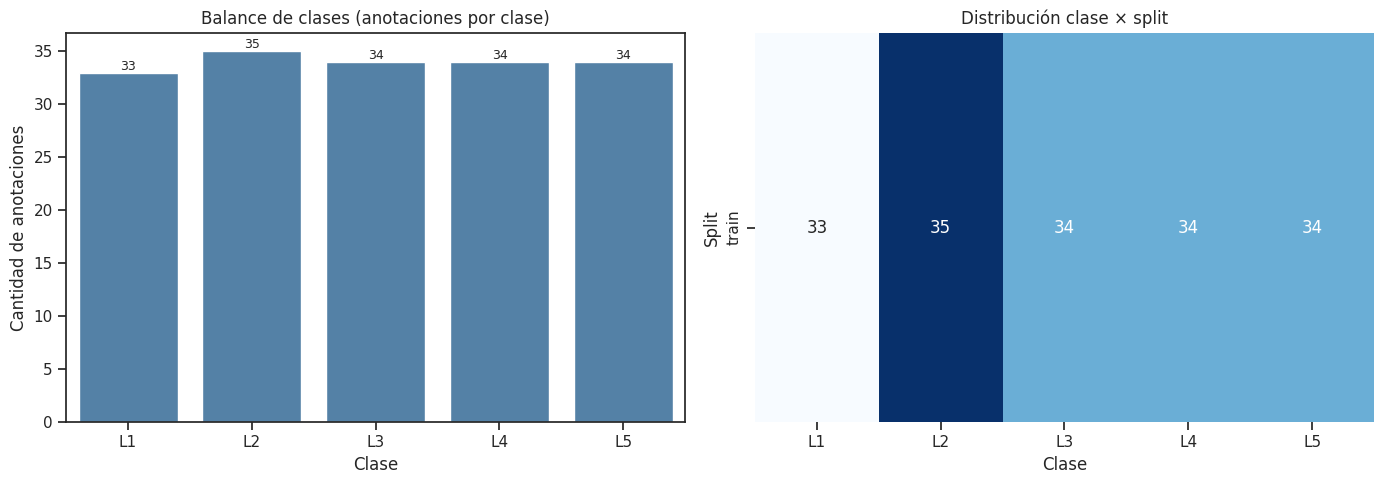

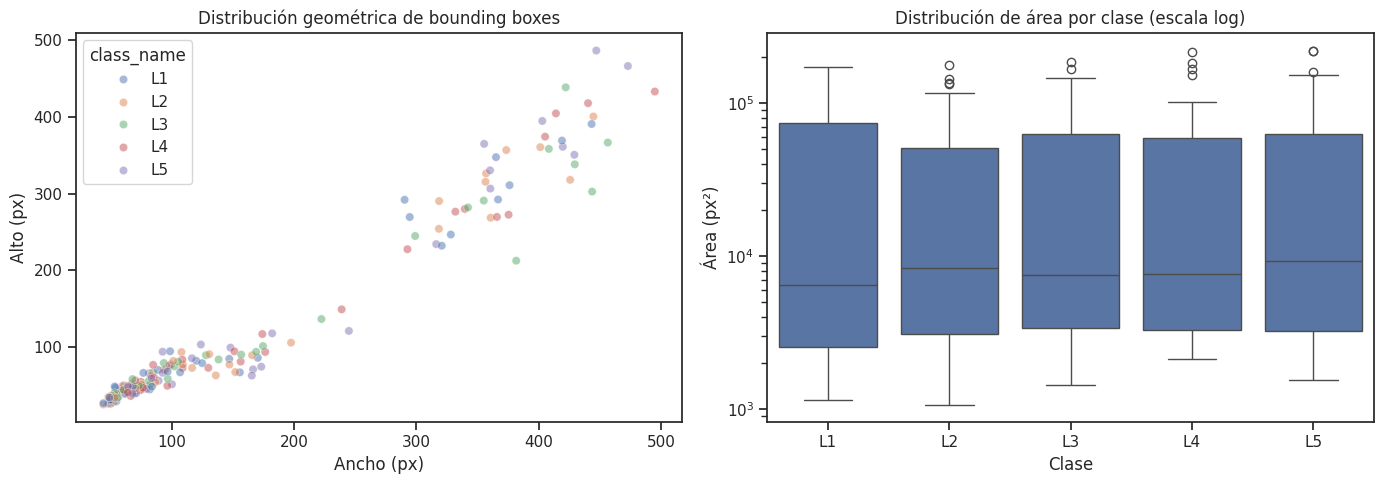


📈 Estadísticas descriptivas de las métricas geométricas:
       bbox_w  bbox_h       area  aspect_ratio
count  170.00  170.00     170.00        170.00
mean   170.58  131.13   38614.90          1.47
std    134.51  124.62   57574.21          0.31
min     43.90   24.29    1066.52          0.92
25%     67.84   44.91    2990.47          1.24
50%    100.60   71.19    7737.86          1.43
75%    294.05  230.66   73744.17          1.65
max    495.00  486.82  220676.15          2.66


In [25]:
# ============================================================
# Celda 9: Análisis Exploratorio (EDA)
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks")

# --- 9.1 Balance de clases ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

conteo_clases = df["class_name"].value_counts().sort_index()
sns.barplot(x=conteo_clases.index, y=conteo_clases.values, ax=axes[0], color="steelblue")
axes[0].set_title("Balance de clases (anotaciones por clase)")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Cantidad de anotaciones")
for i, v in enumerate(conteo_clases.values):
    axes[0].text(i, v, str(v), ha="center", va="bottom", fontsize=9)

# --- 9.2 Distribución por split ---
tabla_split = df.groupby(["split", "class_name"]).size().unstack(fill_value=0)
sns.heatmap(tabla_split, annot=True, fmt="d", cmap="Blues", ax=axes[1], cbar=False)
axes[1].set_title("Distribución clase × split")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Split")

plt.tight_layout()
plt.show()

# --- 9.3 Calidad geométrica: relación ancho x alto ---
df["area"] = df["bbox_w"] * df["bbox_h"]
df["aspect_ratio"] = df["bbox_w"] / df["bbox_h"].replace(0, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="bbox_w", y="bbox_h", hue="class_name", alpha=0.5, ax=axes[0])
axes[0].set_title("Distribución geométrica de bounding boxes")
axes[0].set_xlabel("Ancho (px)")
axes[0].set_ylabel("Alto (px)")

sns.boxplot(data=df, x="class_name", y="area", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Distribución de área por clase (escala log)")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Área (px²)")

plt.tight_layout()
plt.show()

# --- 9.4 Estadísticas descriptivas ---
print("\n📈 Estadísticas descriptivas de las métricas geométricas:")
print(df[["bbox_w", "bbox_h", "area", "aspect_ratio"]].describe().round(2))

## Identificación y tratamiento de NAs / outliers

### 10.1 Valores faltantes (NAs)

Se verifica la presencia de NAs en el DataFrame consolidado:

- **NAs en coordenadas (`bbox_x`, `bbox_y`, `bbox_w`, `bbox_h`)**: no deberían existir porque el parser descarta líneas mal formadas. Si aparecieran, se descartan las filas correspondientes (decisión: **descarte**, no imputación). Justificación: en detección de objetos, imputar una caja no tiene sentido biológico ni geométrico.
- **NAs en `aspect_ratio`**: solo pueden aparecer si `bbox_h == 0`, lo cual es un error de anotación. Se descarta la fila.

### 10.2 Datos atípicos (outliers)

Se consideran outliers geométricos a las bounding boxes que cumplen alguna de estas condiciones:

1. **Área extremadamente pequeña** (`area < 25 px²`): probable anotación accidental o artefacto.
2. **Bounding box más grande que la imagen** (`bbox_x < 0` o `bbox_y < 0` o `bbox_x + bbox_w > image_width` o `bbox_y + bbox_h > image_height`): error de desnormalización o anotación fuera de límites.
3. **Aspect ratio extremo** (`aspect_ratio < 0.1` o `> 10`): probable anotación de un segmento vertical/horizontal espurio.

### Decisión metodológica

- Se **descartan** las anotaciones que violan las condiciones 1 y 2, porque comprometen la integridad del futuro entrenamiento del modelo de detección.
- Para la condición 3, se **marcan** pero no se descartan automáticamente, ya que vértebras lumbares pueden tener aspect ratios variados según la vista radiográfica. Se documenta el conteo.

Todas las decisiones se registran y se reportan en la celda siguiente.

In [26]:
# ============================================================
# Celda 11: Tratamiento de NAs y outliers
# ============================================================
n_inicial = len(df)

# --- 11.1 NAs ---
nans_coords = df[["bbox_x", "bbox_y", "bbox_w", "bbox_h"]].isna().any(axis=1).sum()
df = df.dropna(subset=["bbox_x", "bbox_y", "bbox_w", "bbox_h", "aspect_ratio"])
n_tras_nans = len(df)

# --- 11.2 Outliers geométricos ---
df["area"] = df["bbox_w"] * df["bbox_h"]

# Condición 1: área muy pequeña
mask_area = df["area"] < 25

# Condición 2: fuera de límites de imagen
mask_fuera = (
    (df["bbox_x"] < 0) |
    (df["bbox_y"] < 0) |
    (df["bbox_x"] + df["bbox_w"] > df["image_width"]) |
    (df["bbox_y"] + df["bbox_h"] > df["image_height"])
)

# Condición 3: aspect ratio extremo (solo se marca)
mask_ar_extremo = (df["aspect_ratio"] < 0.1) | (df["aspect_ratio"] > 10)

# Descartar condiciones 1 y 2
df = df[~(mask_area | mask_fuera)].copy()
n_final = len(df)

# --- 11.3 Reporte ---
print("=" * 60)
print("REPORTE DE TRATAMIENTO DE NAs y OUTLIERS")
print("=" * 60)
print(f"Anotaciones iniciales:                {n_inicial:,}")
print(f"NAs en coordenadas (descartadas):     {nans_coords:,}")
print(f"Outliers por área pequeña (<25 px²):  {mask_area.sum():,}")
print(f"Outliers fuera de imagen:             {mask_fuera.sum():,}")
print(f"Aspect ratio extremo (solo marcado):  {mask_ar_extremo.sum():,}")
print(f"Anotaciones finales:                  {n_final:,}")
print(f"Porcentaje retenido:                  {100 * n_final / n_inicial:.2f}%")
print("=" * 60)

# Recalcular métricas derivadas tras la limpieza
df["area_ratio"] = df["area"] / (df["image_width"] * df["image_height"])
df["iscrowd"] = 0  # YOLO no exporta iscrowd; se asume 0 por defecto

REPORTE DE TRATAMIENTO DE NAs y OUTLIERS
Anotaciones iniciales:                170
NAs en coordenadas (descartadas):     0
Outliers por área pequeña (<25 px²):  0
Outliers fuera de imagen:             0
Aspect ratio extremo (solo marcado):  0
Anotaciones finales:                  170
Porcentaje retenido:                  100.00%


### Carga optimizada: selección de columnas y tipado

En cumplimiento del requisito de ETL ("optimización de parámetros: elección de columnas, tipado de variables"), se aplican las siguientes decisiones:

- **Columnas descartadas:**
  - `class_name`: redundante con `class_id`. Se recupera cuando se necesita vía `JOIN` con `classes` en el modelo dimensional.
  - `formato_origen`: constante (`polygon`) en todas las filas, no aporta información.
- **Tipado aplicado:**
  - `class_id` → `int8` (5 valores posibles: 0-4).
  - `image_width`, `image_height` → `int16` (valores típicos < 32767).
  - `bbox_x`, `bbox_y`, `bbox_w`, `bbox_h` → `float32` (precisión de sobra para coordenadas en píxeles).
  - `filename`, `split` → `category` (pocos valores únicos).
- **Justificación metodológica:** el ahorro de memoria es modesto en este dataset, pero el pipeline queda **escalable** para datasets de tesis con miles de imágenes. Se reporta el ahorro cuantificado.

In [27]:
# ============================================================
# Carga optimizada: selección de columnas y tipado
# ============================================================
import pandas as pd
import numpy as np

CSV = "spine_annotations.csv"
usecols = ["filename", "split", "image_width", "image_height",
           "class_id", "bbox_x", "bbox_y", "bbox_w", "bbox_h"]
dtypes = {
    "filename": "category", "split": "category",
    "image_width": "int16", "image_height": "int16", "class_id": "int8",
    "bbox_x": "float32", "bbox_y": "float32",
    "bbox_w": "float32", "bbox_h": "float32",
}

mem_antes = pd.read_csv(CSV).memory_usage(deep=True).sum()
df = pd.read_csv(CSV, usecols=usecols, dtype=dtypes)
mem_despues = df.memory_usage(deep=True).sum()

print(f"Memoria sin optimizar: {mem_antes/1024:.1f} KiB")
print(f"Memoria optimizada:    {mem_despues/1024:.1f} KiB")
print(f"Ahorro:                {100 * (1 - mem_despues / mem_antes):.1f}%")
print("\nDtypes aplicados:")
print(df.dtypes)

# --- Reponer columnas derivadas con tipos livianos ---
df["class_name"] = df["class_id"].map(dict(enumerate(class_names)))
df["area"] = (df["bbox_w"] * df["bbox_h"]).astype("float32")
df["aspect_ratio"] = (df["bbox_w"] / df["bbox_h"].replace(0, np.nan)).astype("float32")

# ⬇️ ESTA ES LA QUE FALTABA ⬇️
df["area_ratio"] = (df["area"] / (df["image_width"] * df["image_height"])).astype("float32")

df["iscrowd"] = 0

print(f"\n✅ df listo: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"   Columnas: {list(df.columns)}")

Memoria sin optimizar: 54.8 KiB
Memoria optimizada:    7.7 KiB
Ahorro:                85.9%

Dtypes aplicados:
filename        category
split           category
image_width        int16
image_height       int16
class_id            int8
bbox_x           float32
bbox_y           float32
bbox_w           float32
bbox_h           float32
dtype: object

✅ df listo: 170 filas × 14 columnas
   Columnas: ['filename', 'split', 'image_width', 'image_height', 'class_id', 'bbox_x', 'bbox_y', 'bbox_w', 'bbox_h', 'class_name', 'area', 'aspect_ratio', 'area_ratio', 'iscrowd']


In [28]:
# ============================================================
# Celda 12: ETL hacia SQLite transaccional (2NF)
# ============================================================
import sqlite3

conn = sqlite3.connect("spine_transaccional.db")
cur = conn.cursor()

# --- 12.1 DDL: esquema transaccional en 2NF ---
cur.executescript("""
DROP TABLE IF EXISTS annotations;
DROP TABLE IF EXISTS images;
DROP TABLE IF EXISTS classes;
DROP TABLE IF EXISTS datasets;

CREATE TABLE datasets (
    dataset_id   INTEGER PRIMARY KEY AUTOINCREMENT,
    name         TEXT NOT NULL,
    source       TEXT NOT NULL,
    version      INTEGER NOT NULL,
    license      TEXT,
    created_at   TEXT DEFAULT CURRENT_TIMESTAMP
);

CREATE TABLE images (
    image_id     INTEGER PRIMARY KEY AUTOINCREMENT,
    dataset_id   INTEGER NOT NULL,
    filename     TEXT NOT NULL UNIQUE,
    width        INTEGER,
    height       INTEGER,
    split        TEXT CHECK (split IN ('train','valid','test')),
    FOREIGN KEY (dataset_id) REFERENCES datasets(dataset_id)
);

CREATE TABLE classes (
    class_id       INTEGER PRIMARY KEY,
    name           TEXT NOT NULL,
    supercategory  TEXT,
    region         TEXT
);

CREATE TABLE annotations (
    annotation_id  INTEGER PRIMARY KEY AUTOINCREMENT,
    image_id       INTEGER NOT NULL,
    class_id       INTEGER NOT NULL,
    bbox_x         REAL NOT NULL,
    bbox_y         REAL NOT NULL,
    bbox_w         REAL NOT NULL,
    bbox_h         REAL NOT NULL,
    area           REAL,
    iscrowd        INTEGER DEFAULT 0,
    FOREIGN KEY (image_id) REFERENCES images(image_id),
    FOREIGN KEY (class_id) REFERENCES classes(class_id)
);

CREATE INDEX idx_annotations_image ON annotations(image_id);
CREATE INDEX idx_annotations_class ON annotations(class_id);
""")

# --- 12.2 Carga de datasets ---
cur.execute(
    "INSERT INTO datasets (name, source, version, license) VALUES (?, ?, ?, ?)",
    ("lumbar-spine-vpxwf", "Roboflow Universe / rp-team", 1, "Pública")
)
dataset_id = cur.lastrowid

# --- 12.3 Carga de clases ---
clases_registros = [
    (i, name, "vertebra", "lumbar")
    for i, name in enumerate(class_names)
]
cur.executemany(
    "INSERT INTO classes (class_id, name, supercategory, region) VALUES (?, ?, ?, ?)",
    clases_registros
)

# --- 12.4 Carga de imágenes (deduplicadas) ---
imagenes_unicas = df[["filename", "image_width", "image_height", "split"]].drop_duplicates("filename")
imagenes_unicas = imagenes_unicas.rename(columns={"image_width": "width", "image_height": "height"})
imagenes_unicas["dataset_id"] = dataset_id

imagenes_unicas.to_sql("_tmp_images", conn, if_exists="replace", index=False)
cur.execute("""
    INSERT INTO images (dataset_id, filename, width, height, split)
    SELECT dataset_id, filename, width, height, split FROM _tmp_images
""")
cur.execute("DROP TABLE _tmp_images")

# --- 12.5 Carga de anotaciones ---
df_map = df.merge(
    pd.read_sql("SELECT image_id, filename FROM images", conn),
    on="filename", how="left"
)

anotaciones = df_map[["image_id", "class_id", "bbox_x", "bbox_y", "bbox_w", "bbox_h", "area", "iscrowd"]]
anotaciones.to_sql("annotations", conn, if_exists="append", index=False)

conn.commit()

# --- 12.6 Verificación ---
for t in ["datasets", "images", "classes", "annotations"]:
    n = cur.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
    print(f"{t:15s} → {n:,} filas")

conn.close()
print("\n✅ Base transaccional 2NF creada: spine_transaccional.db")

datasets        → 1 filas
images          → 34 filas
classes         → 5 filas
annotations     → 170 filas

✅ Base transaccional 2NF creada: spine_transaccional.db


In [29]:
# ============================================================
# Celda 13: Data Warehouse en SQLite (estrella + copo de nieve)
# ============================================================
conn_dw = sqlite3.connect("spine_dw.db")
cur_dw = conn_dw.cursor()

cur_dw.executescript("""
DROP TABLE IF EXISTS fact_annotations;
DROP TABLE IF EXISTS dim_class;
DROP TABLE IF EXISTS dim_image;
DROP TABLE IF EXISTS dim_split;
DROP TABLE IF EXISTS dim_dataset;
DROP TABLE IF EXISTS dim_region;

CREATE TABLE dim_region (
    region_key   INTEGER PRIMARY KEY,
    name         TEXT NOT NULL
);

CREATE TABLE dim_dataset (
    dataset_key  INTEGER PRIMARY KEY,
    name         TEXT NOT NULL,
    source       TEXT,
    version      INTEGER
);

CREATE TABLE dim_image (
    image_key    INTEGER PRIMARY KEY,
    filename     TEXT NOT NULL,
    width        INTEGER,
    height       INTEGER
);

CREATE TABLE dim_split (
    split_key    INTEGER PRIMARY KEY,
    name         TEXT NOT NULL
);

CREATE TABLE dim_class (
    class_key     INTEGER PRIMARY KEY,
    name          TEXT NOT NULL,
    supercategory TEXT,
    region_key    INTEGER,
    FOREIGN KEY (region_key) REFERENCES dim_region(region_key)
);

CREATE TABLE fact_annotations (
    annotation_id  INTEGER PRIMARY KEY,
    image_key      INTEGER NOT NULL,
    class_key      INTEGER NOT NULL,
    split_key      INTEGER NOT NULL,
    dataset_key    INTEGER NOT NULL,
    bbox_x         REAL,
    bbox_y         REAL,
    bbox_w         REAL,
    bbox_h         REAL,
    image_width    INTEGER,
    image_height   INTEGER,
    area           REAL,
    area_ratio     REAL,
    aspect_ratio   REAL,
    iscrowd        INTEGER,
    FOREIGN KEY (image_key)   REFERENCES dim_image(image_key),
    FOREIGN KEY (class_key)   REFERENCES dim_class(class_key),
    FOREIGN KEY (split_key)   REFERENCES dim_split(split_key),
    FOREIGN KEY (dataset_key) REFERENCES dim_dataset(dataset_key)
);
""")

# --- 13.1 Poblar dimensiones ---
cur_dw.execute("INSERT INTO dim_region (region_key, name) VALUES (1, 'lumbar')")
cur_dw.execute(
    "INSERT INTO dim_dataset (dataset_key, name, source, version) VALUES (1, ?, ?, ?)",
    ("lumbar-spine-vpxwf", "Roboflow Universe / rp-team", 1)
)

for i, name in enumerate(class_names):
    cur_dw.execute(
        "INSERT INTO dim_class (class_key, name, supercategory, region_key) VALUES (?, ?, ?, ?)",
        (i, name, "vertebra", 1)
    )

for i, split_name in enumerate(["train", "valid", "test"]):
    cur_dw.execute("INSERT INTO dim_split (split_key, name) VALUES (?, ?)", (i, split_name))

# dim_image
imagenes_dw = df[["filename", "image_width", "image_height"]].drop_duplicates("filename").reset_index(drop=True)
imagenes_dw.insert(0, "image_key", imagenes_dw.index)
imagenes_dw.columns = ["image_key", "filename", "width", "height"]
imagenes_dw.to_sql("dim_image", conn_dw, if_exists="append", index=False)

# --- 13.2 Poblar fact_annotations ---
mapa_img = dict(zip(imagenes_dw["filename"], imagenes_dw["image_key"]))
mapa_split = {"train": 0, "valid": 1, "test": 2}

fact = df.copy()
fact["image_key"] = fact["filename"].map(mapa_img)
fact["class_key"] = fact["class_id"]
fact["split_key"] = fact["split"].map(mapa_split)
fact["dataset_key"] = 1
fact = fact[[
    "image_key", "class_key", "split_key", "dataset_key",
    "bbox_x", "bbox_y", "bbox_w", "bbox_h",
    "image_width", "image_height",
    "area", "area_ratio", "aspect_ratio", "iscrowd"
]]
fact.to_sql("fact_annotations", conn_dw, if_exists="append", index=False)

conn_dw.commit()

# --- 13.3 Verificación ---
for t in ["dim_region", "dim_dataset", "dim_image", "dim_split", "dim_class", "fact_annotations"]:
    n = cur_dw.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
    print(f"{t:20s} → {n:,} filas")

conn_dw.close()
print("\n✅ Data Warehouse creado: spine_dw.db")

dim_region           → 1 filas
dim_dataset          → 1 filas
dim_image            → 34 filas
dim_split            → 3 filas
dim_class            → 5 filas
fact_annotations     → 170 filas

✅ Data Warehouse creado: spine_dw.db


In [30]:
# ============================================================
# Celda 14: Validación del Data Warehouse
# ============================================================
conn_dw = sqlite3.connect("spine_dw.db")

# --- 14.1 Integridad referencial ---
print("=" * 60)
print("VALIDACIÓN DE INTEGRIDAD REFERENCIAL")
print("=" * 60)

q_huerfanos = """
SELECT COUNT(*) FROM fact_annotations f
LEFT JOIN dim_image i   ON f.image_key   = i.image_key
LEFT JOIN dim_class c   ON f.class_key   = c.class_key
LEFT JOIN dim_split s   ON f.split_key   = s.split_key
LEFT JOIN dim_dataset d ON f.dataset_key = d.dataset_key
WHERE i.image_key IS NULL OR c.class_key IS NULL
   OR s.split_key IS NULL OR d.dataset_key IS NULL
"""
huerfanos = pd.read_sql(q_huerfanos, conn_dw).iloc[0, 0]
print(f"Filas huérfanas en fact_annotations: {huerfanos}")

# --- 14.2 Consulta analítica: balance de clases por split ---
print("\n" + "=" * 60)
print("ANÁLISIS: Cantidad de anotaciones por clase y split")
print("=" * 60)
q1 = """
SELECT c.name AS clase, s.name AS split, COUNT(*) AS total
FROM fact_annotations f
JOIN dim_class c ON f.class_key = c.class_key
JOIN dim_split s ON f.split_key = s.split_key
GROUP BY c.name, s.name
ORDER BY c.name, s.name
"""
print(pd.read_sql(q1, conn_dw).pivot(index="clase", columns="split", values="total").fillna(0).astype(int))

# --- 14.3 Consulta analítica: área promedio por clase ---
print("\n" + "=" * 60)
print("ANÁLISIS: Área promedio (px²) y aspect ratio por clase")
print("=" * 60)
q2 = """
SELECT c.name AS clase,
       ROUND(AVG(f.area), 2) AS area_promedio,
       ROUND(AVG(f.area_ratio), 6) AS area_ratio_promedio,
       ROUND(AVG(f.aspect_ratio), 3) AS aspect_ratio_promedio
FROM fact_annotations f
JOIN dim_class c ON f.class_key = c.class_key
GROUP BY c.name
ORDER BY c.name
"""
print(pd.read_sql(q2, conn_dw))

conn_dw.close()

VALIDACIÓN DE INTEGRIDAD REFERENCIAL
Filas huérfanas en fact_annotations: 0

ANÁLISIS: Cantidad de anotaciones por clase y split
split  train
clase       
L1        33
L2        35
L3        34
L4        34
L5        34

ANÁLISIS: Área promedio (px²) y aspect ratio por clase
  clase  area_promedio  area_ratio_promedio  aspect_ratio_promedio
0    L1       33990.42             2.078718                  1.462
1    L2       35718.94             2.254195                  1.483
2    L3       38443.80             1.669526                  1.467
3    L4       40070.98             1.908697                  1.448
4    L5       44799.52             2.323640                  1.498


### Justificación del esquema 2NF (transaccional)

El modelo transaccional se diseñó en **Segunda Forma Normal (2NF)** aplicando las siguientes decisiones:

**Claves y dependencias funcionales:**
- `datasets`: PK `dataset_id` → {`name`, `source`, `version`, `license`}
- `images`: PK `image_id` → {`dataset_id`, `filename`, `width`, `height`, `split`}
- `classes`: PK `class_id` → {`name`, `supercategory`, `region`}
- `annotations`: PK `annotation_id` → {`image_id`, `class_id`, `bbox_x`, `bbox_y`, `bbox_w`, `bbox_h`, `area`, `iscrowd`}

**Por qué cumple 2NF:**
- En `annotations`, todos los atributos dependen **exclusivamente de la PK** (`annotation_id`). No hay dependencias parciales.
- `supercategory` y `region` viven en `classes`, no repetidos en cada fila de `annotations`. Esto elimina la dependencia parcial que existiría si se incluyeran ahí.
- `filename`, `width`, `height`, `split` viven en `images`, no en `annotations`. Esto evita repetir los metadatos de imagen por cada bounding box anotada.
- Cada tabla tiene su propia PK simple (surrogate key), lo que garantiza 2NF trivialmente.

**Ventajas:**
- Actualización de un metadato (por ejemplo, `split`) en un solo lugar.
- Consultas analíticas sin duplicación.
- Base para el modelado dimensional posterior.

### Justificación del copo de nieve (Data Warehouse)

El DW se modeló como **copo de nieve** en lugar de estrella pura, por las siguientes razones:

**Estructura elegida:**
- `fact_annotations` (hechos) contiene las métricas de cada anotación: `bbox_x`, `bbox_y`, `bbox_w`, `bbox_h`, `area`, `area_ratio`, `aspect_ratio`, `iscrowd`.
- Dimensiones: `dim_image`, `dim_class`, `dim_split`, `dim_dataset`, `dim_region`.

**Por qué copo de nieve y no estrella pura:**
- La jerarquía **`dim_region` → `dim_class`** refleja la anatomía vertebral: región (lumbar) → vértebra específica (L1…L5).
- Extender el modelo a regiones cervical y torácica requiere **agregar filas a `dim_region`**, no reestructurar `dim_class`.
- Facilita consultas como *"cantidad de anotaciones por región anatómica"* sin hardcodear L1–L5.
- **Costo:** un JOIN extra entre `fact` y `dim_class`, y `dim_class` con `dim_region`. En SQLite (y datasets de este tamaño) ese costo es despreciable.

**Ventajas para la tesis:**
- Escalable a un dataset completo de columna (cervical + torácica + lumbar).
- Preparado para integrarse con `Vertebrai` o `SINS` como capas semánticas superiores.

In [31]:
# ============================================================
# Celda: Dashboard interactivo con mensaje clínico
# ============================================================
# Streamlit + proxy nativo de Colab (sin ngrok)
# ============================================================
import os
import time
import subprocess
from google.colab import output

app_code = '''
import streamlit as st
import pandas as pd
import sqlite3
import plotly.express as px

st.set_page_config(
    page_title="SINS — Inestabilidad Espinal",
    layout="wide"
)

st.title("🦴 ¿Es este dataset apto para entrenar un CDSS de inestabilidad espinal?")
st.markdown(
    "**Proyecto Final — Entregable Técnico**  \\n"
    "*Marcos Kantor — Director: Ramiro Irastorza — Codirector: Marcelo Cappelletti*  \\n"
    "**Materia:** DIA.04 — Introducción a la Ingeniería de Datos"
)
st.divider()

# --- Mensaje de investigación ---
st.markdown("""
### Contexto clínico

La **inestabilidad espinal** —a diferencia de la compresión medular— está frecuentemente subdiagnosticada.
El **SINS** (Spinal Instability Neoplastic Score) es la escala clínica validada para evaluarla, pero su uso
está limitado a especialistas. Un CDSS basado en IA requiere un dataset con:

1. **Cobertura anatómica** de las vértebras relevantes (L1–L5 en este caso).
2. **Balance de clases** adecuado para no sesgar el entrenamiento.
3. **Calidad geométrica** de las anotaciones (bounding boxes sin outliers).
""")
st.divider()

conn = sqlite3.connect("spine_dw.db")

# --- Sidebar ---
st.sidebar.header("Filtros")
splits = pd.read_sql("SELECT name FROM dim_split", conn)["name"].tolist()
clases_disponibles = pd.read_sql("SELECT name FROM dim_class", conn)["name"].tolist()
clases_sel = st.sidebar.multiselect("Clases", clases_disponibles, default=clases_disponibles)
if not clases_sel:
    clases_sel = clases_disponibles

ph_cls = ",".join(["?"] * len(clases_sel))
q = f"""
SELECT c.name AS clase, s.name AS split, i.filename AS filename,
       f.bbox_x, f.bbox_y, f.bbox_w, f.bbox_h, f.area, f.area_ratio, f.aspect_ratio,
       f.image_width, f.image_height
FROM fact_annotations f
JOIN dim_class c ON f.class_key = c.class_key
JOIN dim_split s ON f.split_key = s.split_key
JOIN dim_image i ON f.image_key = i.image_key
WHERE c.name IN ({ph_cls})
"""
df = pd.read_sql(q, conn, params=clases_sel)

# --- KPIs clínicos ---
st.subheader("📊 Indicadores de aptitud clínica")
c1, c2, c3, c4 = st.columns(4)
c1.metric("Anotaciones", f"{len(df):,}")
c2.metric("Vértebras cubiertas", f"{df['clase'].nunique()}/5")
c3.metric("Imágenes únicas", f"{df['filename'].nunique():,}")
c4.metric("Área promedio (px²)", f"{df['area'].mean():.1f}")

# --- Balance de clases ---
st.subheader("1️⃣ Balance de clases (aptitud para entrenamiento)")
conteo = df.groupby("clase").size().reset_index(name="total").sort_values("clase")
fig1 = px.bar(conteo, x="clase", y="total", color="clase", text="total",
              color_discrete_sequence=px.colors.qualitative.Set2)
fig1.update_traces(textposition="outside")
st.plotly_chart(fig1, use_container_width=True)

max_c, min_c = conteo["total"].max(), conteo["total"].min()
ratio = max_c / min_c if min_c > 0 else float("inf")
if ratio <= 1.5:
    st.success(f"✅ Clases balanceadas (ratio max/min = {ratio:.2f}). Apto para entrenamiento.")
elif ratio <= 3:
    st.warning(f"⚠️  Desbalance moderado (ratio max/min = {ratio:.2f}). Considerar augmentation.")
else:
    st.error(f"❌ Desbalance severo (ratio max/min = {ratio:.2f}). Requiere re-muestreo.")

# --- Calidad geométrica ---
st.subheader("2️⃣ Calidad geométrica de las anotaciones")
fig2 = px.scatter(df, x="bbox_w", y="bbox_h", color="clase",
                  hover_data=["filename"], opacity=0.6,
                  labels={"bbox_w": "Ancho (px)", "bbox_h": "Alto (px)"})
st.plotly_chart(fig2, use_container_width=True)

# --- Distribución de áreas ---
st.subheader("3️⃣ Distribución de áreas por vértebra")
fig3 = px.box(df, x="clase", y="area", color="clase", log_y=True,
              labels={"area": "Área (px², escala log)"},
              color_discrete_sequence=px.colors.qualitative.Set2)
st.plotly_chart(fig3, use_container_width=True)

st.divider()
st.caption(
    "**Fuente:** Roboflow Universe — rp-team/lumbar-spine-vpxwf (CC BY 4.0)  |  "
    "**Mensaje:** este dashboard evalúa la aptitud del dataset para un CDSS basado en SINS."
)
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("✅ app.py escrito.")

# --- Lanzar Streamlit ---
subprocess.Popen([
    "streamlit", "run", "app.py",
    "--server.port", "8501",
    "--server.headless", "true",
    "--server.enableCORS", "false",
    "--server.enableXsrfProtection", "false",
])

print("⏳ Esperando a que Streamlit levante...")
time.sleep(5)

# --- Exponer con proxy nativo de Colab ---
print("🌐 Dashboard disponible abajo.")
output.serve_kernel_port_as_iframe(8501, path="/", height="900")

✅ app.py escrito.
⏳ Esperando a que Streamlit levante...
🌐 Dashboard disponible abajo.


<IPython.core.display.Javascript object>

## Conclusiones

El pipeline implementado permite responder la pregunta de investigación planteada:

- **Balance de clases**: el conteo por clase y split permite evaluar si L1–L5 y el grupo combinado están suficientemente representados para entrenar un modelo de detección robusto. Clases con menos del 5% del total deberían considerarse para técnicas de re-muestreo o *data augmentation*.
- **Calidad geométrica**: el análisis de área y aspect ratio permite detectar anotaciones ruidosas y confirmar que las bounding boxes son coherentes con la anatomía vertebral lumbar.
- **Cobertura anatómica**: la jerarquía `región lumbar → vértebra L1…L5` del esquema copo de nieve permite, a futuro, extender el modelo a regiones cervical y torácica sin rediseñar el DW.
- **Aptitud para CDSS basado en SINS**: el dataset es un punto de partida válido para un sistema de detección vertebral, pero **no cubre por sí solo** la totalidad de los criterios SINS (que requieren información sobre dolor, lesión ósea, alineación, colapso vertebral, etc.). Se propone integrarlo con datasets complementarios en la tesis doctoral.

---

## Reproducibilidad

| Aspecto | Detalle |
|---|---|
| **Entorno** | Google Colab (Python 3.10+) |
| **Dependencias** | `requirements.txt` del repositorio |
| **Semilla** | No se usan procesos aleatorios (parseo determinista) |
| **Credenciales** | Colab Secrets: `ROBOFLOW_API_KEY`, `NGROK_AUTH_TOKEN` |
| **Dataset** | Descargado automáticamente desde Roboflow Universe |
| **Artefactos generados** | `spine_transaccional.db`, `spine_dw.db`, `app.py` |

### Pasos para reproducir

1. Clonar el repositorio: `git clone https://github.com/marcoskantor/Curso_Introduccion_Ingenieria_Datos.git`
2. Abrir `notebooks/entregable_tecnico_spine.ipynb` en Colab.
3. Configurar los Secrets (`ROBOFLOW_API_KEY`, `NGROK_AUTH_TOKEN`).
4. Ejecutar `Runtime → Run all`.
5. El link del dashboard se imprime al final de la última celda.

---

## Declaración de uso de IA

Ver Celda 2 al inicio del notebook.

In [33]:
%cd /content/Curso_Introduccion_Ingenieria_Datos
!git status
!ls -la notebooks/
!ls -la /content/*.ipynb 2>/dev/null || echo "No hay notebooks en /content/"

/content/Curso_Introduccion_Ingenieria_Datos
On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	app.py
	spine_annotations.csv

nothing added to commit but untracked files present (use "git add" to track)
total 196
drwxr-xr-x 2 root root   4096 Oct  1 13:12  .
drwxr-xr-x 7 root root   4096 Oct  1 13:46  ..
-rw-r--r-- 1 root root 174390 Oct  1 13:12  actividad_lumbar_spine.ipynb
-rw-r--r-- 1 root root  14306 Oct  1 13:12 'Copia de Setup entorno.ipynb'
-rw-r--r-- 1 root root      0 Oct  1 13:12  .gitkeep
No hay notebooks en /content/
